# TB Treatment Outcome Prediction — Improved Models (SMOTE+Tomek + Extended Features)

**Dataset:** TB Case Notifications, Cordillera Administrative Region (CAR), Philippines (2015–2025)  
**Task:** Binary classification — predict **Treatment Success** vs **Treatment Failure**  
**Approach:** Improve on baseline with SMOTE+Tomek resampling and additional features

### Improvements over Baseline

| # | Improvement | Why |
|---|---|---|
| 1 | **Extra pre-encoded features** | Add City/Municipality, Treatment Health Facility, and other encoded columns not in baseline |
| 2 | **Derived delay feature** | Diagnosis → Treatment delay (only derivable date pair remaining in ml-ready) |
| 3 | **SMOTE+Tomek resampling** | SMOTE oversamples Failure class synthetically, then Tomek Links removes borderline majority-class samples that form Tomek pairs (nearest-neighbor pairs from opposite classes) |

> **Focus metric: Recall on Failure class** — for a CDSS, missing a likely failure is more harmful than a false alarm.
> SMOTE+Tomek focuses on borderline samples by removing Tomek pairs, helping establish a cleaner majority-class boundary.

## 1. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE+Tomek (combines SMOTE oversampling + Tomek Links undersampling)
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Utilities
import time
import joblib
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directories
img_dir = Path('smotetomek_outputs/images')
model_dir = Path('smotetomek_outputs/models')
img_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading and Target Engineering

In [2]:
# Load the ML-ready dataset (features already label-encoded + standard-scaled)
df_raw = pd.read_csv('../dataset/non-temporal/2015-2025-ml-ready.csv')
print(f'ML-ready dataset shape: {df_raw.shape}')

# ── Decode Outcome/Status back to original labels ─────────────────────────
OUTCOME_LABELS_ALPHA = [
    'CURED', 'DIAGNOSED', 'DIED', 'EXCLUDED', 'FAILED', 'LOST TO FF-UP',
    'NOT ENROLLED', 'NOT EVALUATED', 'ON TREATMENT', 'Screened', 'TREATMENT COMPLETED'
]
outcome_encoded_sorted = sorted(df_raw['Outcome/Status'].dropna().unique())
OUTCOME_DECODE = dict(zip(outcome_encoded_sorted, OUTCOME_LABELS_ALPHA))
df_raw['Outcome_Label'] = df_raw['Outcome/Status'].map(OUTCOME_DECODE)

# Define target variable
SUCCESS_OUTCOMES = {'TREATMENT COMPLETED', 'CURED'}
FAILURE_OUTCOMES = {'DIED', 'LOST TO FF-UP', 'FAILED'}

df = df_raw[df_raw['Outcome_Label'].isin(SUCCESS_OUTCOMES | FAILURE_OUTCOMES)].copy()
df['Target'] = df['Outcome_Label'].apply(lambda x: 1 if x in SUCCESS_OUTCOMES else 0)

print(f'Usable records: {len(df):,}')
class_counts = df['Target'].value_counts()
print(f"  Success (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"  Failure (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)")

ML-ready dataset shape: (7389, 28)
Usable records: 6,797
  Success (1): 5,858 (86.2%)
  Failure (0): 939 (13.8%)


## 3. Feature Engineering (Extended Features + Derived Delay)

In [3]:
# ── Derive delay feature from remaining date-string columns ───────────────
# In ml-ready.csv, only 'Date Started Tx' and 'Date of Diagnosis' are still date strings.
df['_Date_Started_Tx'] = pd.to_datetime(df['Date Started Tx'], errors='coerce')
df['_Date_of_Diagnosis'] = pd.to_datetime(df['Date of Diagnosis'], errors='coerce')

df['Diagnosis_to_Treatment_days'] = (
    df['_Date_Started_Tx'] - df['_Date_of_Diagnosis']
).dt.days.clip(lower=0)

non_null = df['Diagnosis_to_Treatment_days'].notna().sum()
print(f'Derived delay feature:')
print(f"  Diagnosis_to_Treatment_days: {non_null:,}/{len(df):,} non-null ({non_null/len(df)*100:.1f}%)")

Derived delay feature:
  Diagnosis_to_Treatment_days: 2,914/6,797 non-null (42.9%)


In [4]:
# ── Improved feature set ───────────────────────────────────────────────────
# Baseline features + additional pre-encoded geographic/facility features + delay feature
IMP_FEATURES = [
    # --- Baseline features (all pre-encoded & scaled) ---
    'Age',
    'Days_To_Treatment',
    'Year',
    'Sex',
    'Anatomical Site',
    'Registration Group',
    'Bacteriologic Status',
    'Microscopy Result',
    'Source of Patient',
    'Type',
    'Province',
    'City/Municipality',
    'Treatment Health Facility',
    'Screening/Diagnosing Health Facility',
    # --- Derived delay feature (raw days, needs scaling) ---
    'Diagnosis_to_Treatment_days',
]

X = df[IMP_FEATURES].copy()
y = df['Target'].values

# Fill Age from Computed_Age where missing
X['Age'] = X['Age'].fillna(df['Computed_Age'])

print(f'Improved feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'  Pre-encoded ({len(IMP_FEATURES)-1}): already scaled from ml-ready.csv')
print(f'  Derived (1): Diagnosis_to_Treatment_days (raw days, will be imputed+scaled)')
print(f'\nMissing values:')
print(X.isnull().sum())

Improved feature matrix: 6,797 rows × 15 features
  Pre-encoded (14): already scaled from ml-ready.csv
  Derived (1): Diagnosis_to_Treatment_days (raw days, will be imputed+scaled)

Missing values:
Age                                        0
Days_To_Treatment                          0
Year                                       0
Sex                                        0
Anatomical Site                            0
Registration Group                         0
Bacteriologic Status                       0
Microscopy Result                          0
Source of Patient                          0
Type                                       0
Province                                   0
City/Municipality                          0
Treatment Health Facility                  0
Screening/Diagnosing Health Facility       0
Diagnosis_to_Treatment_days             3883
dtype: int64


## 4. Preprocessing Pipeline

In [5]:
# ── Improved preprocessing pipeline ───────────────────────────────────────
# Most features are already scaled; the derived delay feature needs scaling too.
PRE_ENCODED_FEATURES = [f for f in IMP_FEATURES if f != 'Diagnosis_to_Treatment_days']
DERIVED_FEATURES = ['Diagnosis_to_Treatment_days']

preprocessor = ColumnTransformer(transformers=[
    ('passthrough', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]), PRE_ENCODED_FEATURES),
    ('derived', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), DERIVED_FEATURES),
])

# ── Stratified train/test split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Failure class in train: {(y_train == 0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'Failure class in test : {(y_test == 0).sum():,} ({(y_test==0).mean()*100:.1f}%)')

Train: 5,437  |  Test: 1,360
Failure class in train: 751 (13.8%)
Failure class in test : 188 (13.8%)


## 5. Model Training with SMOTE+Tomek

In [6]:

# ── Helper: extract iteration / epoch count from a fitted estimator ────────
def get_iterations(clf):
    """
    Return the number of iterations (epochs) or trees for a fitted model.
      • Iterative  (LR, MLP, SVM) : n_iter_ until convergence / early-stop
      • Ensemble   (RF, ET, GB)   : n_estimators (trees / boosting stages)
      • Boosting   (XGB, LGB)     : n_estimators (configured stages)
      • AdaBoost                  : n_estimators_ (actual estimators used)
      • Non-iterative (KNN, NB, DT): '—'
    """
    if hasattr(clf, 'n_iter_'):
        ni = clf.n_iter_
        if hasattr(ni, '__len__'):
            return int(max(ni))   # MLP → max epochs; SVM → max across classes
        return int(ni)            # LR  → scalar iterations to convergence
    if hasattr(clf, 'n_estimators_'):
        return int(clf.n_estimators_)   # AdaBoost: actual estimators used
    if hasattr(clf, 'n_estimators'):
        return int(clf.n_estimators)    # RF, GB, XGB, LGB
    return '—'


# ── Train improved models with SMOTE+Tomek ──────────────────────────────────
IMP_MODELS = {
    'Logistic Regression + SMOTETomek': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight=None
    ),
    'Random Forest + SMOTETomek': RandomForestClassifier(
        n_estimators=300, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting + SMOTETomek': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost + SMOTETomek': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        n_jobs=-1, verbosity=0
    ),
    'LightGBM + SMOTETomek': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

smotetomek = SMOTETomek(random_state=RANDOM_STATE)

imp_results = []
imp_trained_pipelines = {}

for name, model in IMP_MODELS.items():
    print(f'Training {name}...', end='  ', flush=True)
    t0 = time.time()

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smotetomek',     smotetomek),
        ('classifier',   model),
    ])
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    clf = pipe.named_steps['classifier']
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred,
                                   target_names=['Failure', 'Success'],
                                   output_dict=True, zero_division=0)
    imp_results.append({
        'Model':               name,
        'Accuracy':            accuracy_score(y_test, y_pred),
        'ROC-AUC':             roc_auc_score(y_test, y_proba),
        'F1 (Failure)':        report['Failure']['f1-score'],
        'Recall (Failure)':    report['Failure']['recall'],
        'Precision (Failure)': report['Failure']['precision'],
        'F1 (Success)':        report['Success']['f1-score'],
        'Recall (Success)':    report['Success']['recall'],
        'Train Time (s)':      round(train_time, 2),
        'Iterations / Trees':  get_iterations(clf),
    })
    imp_trained_pipelines[name] = pipe
    print(f'done ({train_time:.1f}s,  iters/trees={get_iterations(clf)})')

imp_df = pd.DataFrame(imp_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
imp_df.index += 1

display_cols = ['Model', 'ROC-AUC', 'Recall (Failure)', 'F1 (Failure)',
                'Recall (Success)', 'Accuracy', 'Train Time (s)', 'Iterations / Trees']
print('\n' + '='*105)
print('IMPROVED MODELS (SMOTE+Tomek + Extended Features) — sorted by ROC-AUC')
print('  Iterations/Trees: convergence iters (LR) | n_estimators (ensemble)')
print('='*105)
print(imp_df[display_cols].to_string())

Training Logistic Regression + SMOTETomek...  done (0.6s,  iters/trees=7)
Training Random Forest + SMOTETomek...  done (1.0s,  iters/trees=300)
Training Gradient Boosting + SMOTETomek...  done (4.6s,  iters/trees=300)
Training XGBoost + SMOTETomek...  done (1.2s,  iters/trees=300)
Training LightGBM + SMOTETomek...  done (1.4s,  iters/trees=300)

IMPROVED MODELS (SMOTE+Tomek + Extended Features) — sorted by ROC-AUC
  Iterations/Trees: convergence iters (LR) | n_estimators (ensemble)
                              Model   ROC-AUC  Recall (Failure)  F1 (Failure)  Recall (Success)  Accuracy  Train Time (s)  Iterations / Trees
1        Random Forest + SMOTETomek  0.698429          0.303191      0.293059          0.877133  0.797794            1.00                 300
2    Gradient Boosting + SMOTETomek  0.695674          0.164894      0.237548          0.964164  0.853676            4.63                 300
3             LightGBM + SMOTETomek  0.692660          0.164894      0.227106          

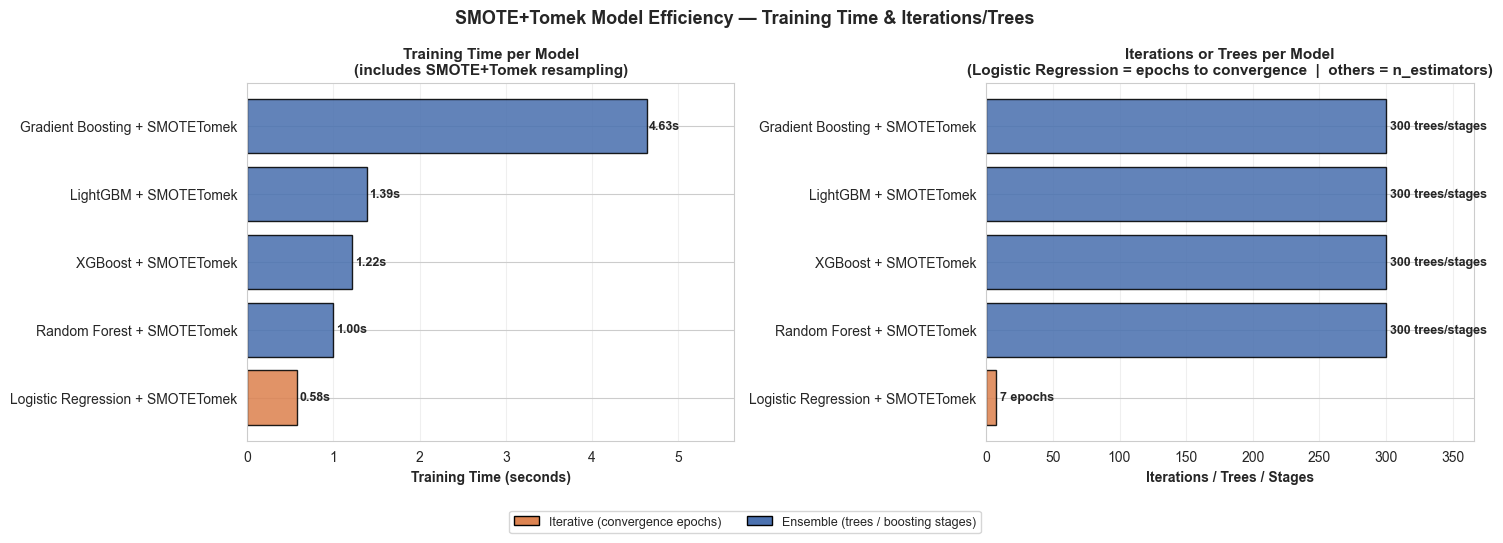

Saved: training_time_iterations_smotetomek.png


In [7]:

# ── Training Time & Iterations / Epochs visualisation ─────────────────────
# LR → iterations to convergence (orange)
# RF, GB, XGB, LGB → trees / boosting stages (blue)

IMP_ITERATIVE = {'Logistic Regression + SMOTETomek'}
IMP_CAT_COLOR = {'iterative': '#DD8452', 'ensemble': '#4C72B0'}
IMP_CAT_LABEL = {
    'iterative': 'Iterative (convergence epochs)',
    'ensemble':  'Ensemble (trees / boosting stages)',
}

def imp_model_category(name):
    return 'iterative' if name in IMP_ITERATIVE else 'ensemble'

plot_imp = (
    imp_df[['Model', 'Train Time (s)', 'Iterations / Trees']]
    .copy()
    .sort_values('Train Time (s)', ascending=True)
    .reset_index(drop=True)
)
plot_imp['Category'] = plot_imp['Model'].apply(imp_model_category)
plot_imp['Color']    = plot_imp['Category'].map(IMP_CAT_COLOR)
plot_imp['IterUnit'] = plot_imp.apply(
    lambda r: 'epochs' if r['Category'] == 'iterative' else 'trees/stages', axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Training Time ────────────────────────────────────────────────────
bars_t = axes[0].barh(
    plot_imp['Model'], plot_imp['Train Time (s)'],
    color=plot_imp['Color'], edgecolor='black', alpha=0.88
)
for bar, val in zip(bars_t, plot_imp['Train Time (s)']):
    axes[0].text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}s', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Training Time (seconds)', fontweight='bold')
axes[0].set_title('Training Time per Model\n(includes SMOTE+Tomek resampling)', fontweight='bold', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, plot_imp['Train Time (s)'].max() * 1.22)

# ── Right: Iterations / Epochs / Trees ────────────────────────────────────
iters = plot_imp['Iterations / Trees'].astype(int)
bars_i = axes[1].barh(
    plot_imp['Model'], iters,
    color=plot_imp['Color'], edgecolor='black', alpha=0.88
)
for bar, val, unit in zip(bars_i, iters, plot_imp['IterUnit']):
    axes[1].text(val + iters.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val} {unit}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Iterations / Trees / Stages', fontweight='bold')
axes[1].set_title('Iterations or Trees per Model\n'
                  '(Logistic Regression = epochs to convergence  |  others = n_estimators)',
                  fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, iters.max() * 1.22)

# ── Legend ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch as MPatch
imp_legend = [MPatch(facecolor=IMP_CAT_COLOR[k], label=IMP_CAT_LABEL[k], edgecolor='black')
              for k in IMP_CAT_COLOR]
fig.legend(handles=imp_legend, loc='lower center', ncol=2,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('SMOTE+Tomek Model Efficiency — Training Time & Iterations/Trees',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/training_time_iterations_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_time_iterations_smotetomek.png')

### 5a. Learning Curves — All Models

How training and validation ROC-AUC change as training data grows.  
*Gap between train and val = overfitting; both lines low = underfitting.*

Learning curve: Logistic Regression + SMOTETomek...
Learning curve: Random Forest + SMOTETomek...
Learning curve: Gradient Boosting + SMOTETomek...
Learning curve: XGBoost + SMOTETomek...
Learning curve: LightGBM + SMOTETomek...


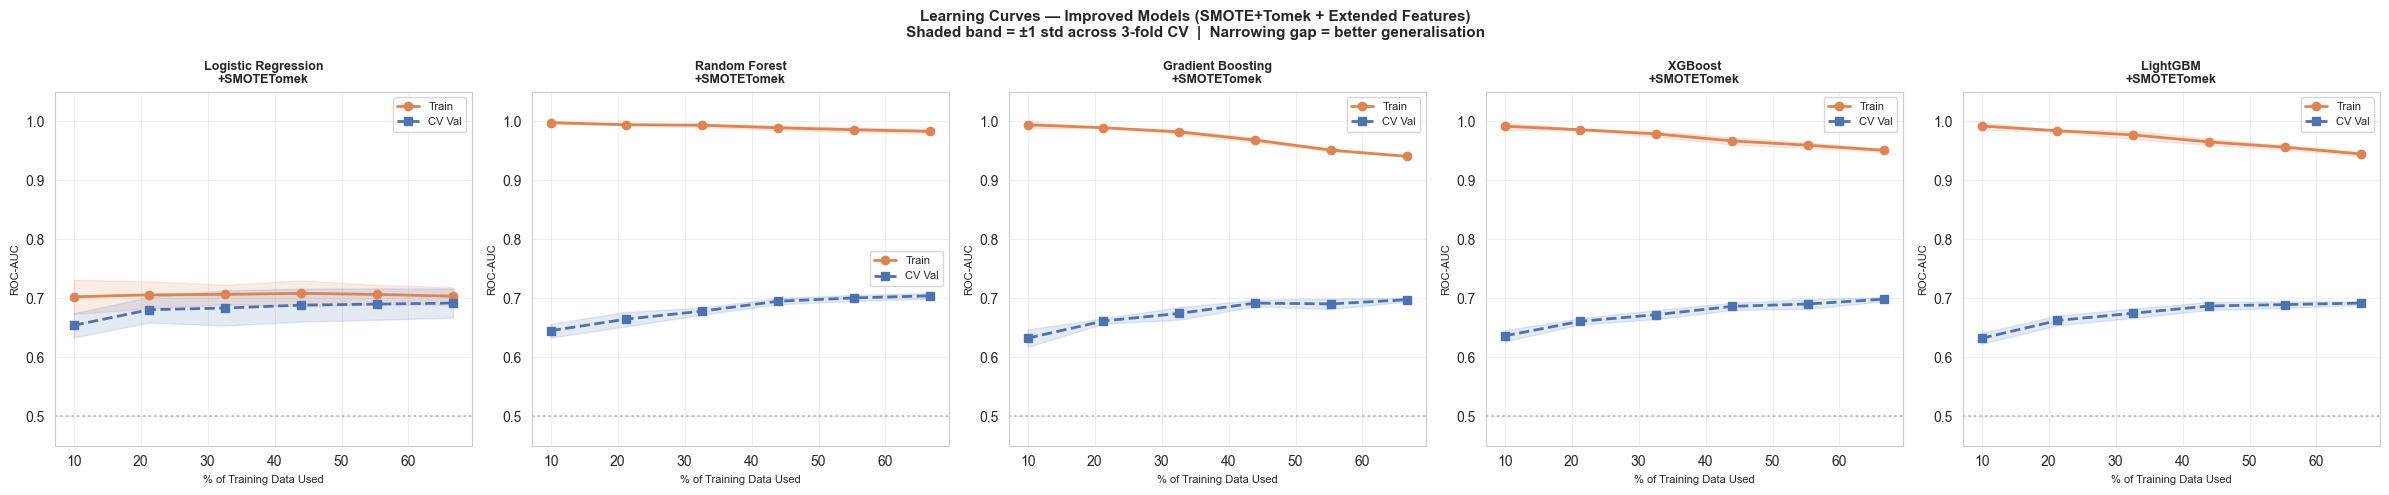


Saved: learning_curves_smotetomek.png


In [8]:

from sklearn.model_selection import learning_curve as sk_learning_curve
from sklearn.base import clone

# ── Learning curves for all 5 improved models ─────────────────────────────
# learning_curve clones the pipeline, so SMOTE+Tomek is applied correctly within
# each training fold only — test fold is never resampled.

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
train_sizes_frac = np.linspace(0.15, 1.0, 6)

for ax, (name, pipe) in zip(axes, imp_trained_pipelines.items()):
    print(f'Learning curve: {name}...', flush=True)
    train_sizes, train_scores, val_scores = sk_learning_curve(
        clone(pipe), X_train, y_train,
        train_sizes=train_sizes_frac,
        cv=3, scoring='roc_auc',
        n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    sizes_pct  = train_sizes / len(X_train) * 100
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes_pct, train_mean, 'o-',  color='#DD8452', label='Train',   linewidth=2)
    ax.fill_between(sizes_pct, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#DD8452')
    ax.plot(sizes_pct, val_mean,   's--', color='#4C72B0', label='CV Val',  linewidth=2)
    ax.fill_between(sizes_pct, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#4C72B0')

    ax.set_title(name.replace(' + SMOTETomek', '\n+SMOTETomek'), fontweight='bold', fontsize=9)
    ax.set_xlabel('% of Training Data Used', fontsize=8)
    ax.set_ylabel('ROC-AUC', fontsize=8)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle(
    'Learning Curves — Improved Models (SMOTE+Tomek + Extended Features)\n'
    'Shaded band = ±1 std across 3-fold CV  |  Narrowing gap = better generalisation',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/learning_curves_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: learning_curves_smotetomek.png')

### 5b. Per-Stage / Epoch Curves — Model-Specific

| Model | Approach |
|---|---|
| **Gradient Boosting** | `staged_predict_proba` → ROC-AUC per boosting stage (1 → 300) |
| **XGBoost / LightGBM** | Retrain with `eval_set` → log-loss per stage tracked natively |
| **Random Forest** | Retrain with increasing `n_estimators` → shows tree-count saturation |
| **Logistic Regression** | Retrain with increasing `max_iter` → convergence per epoch |

GB staged curve...
XGBoost staged curve...
LightGBM staged curve...
Random Forest tree-count curve...
Logistic Regression epoch curve...


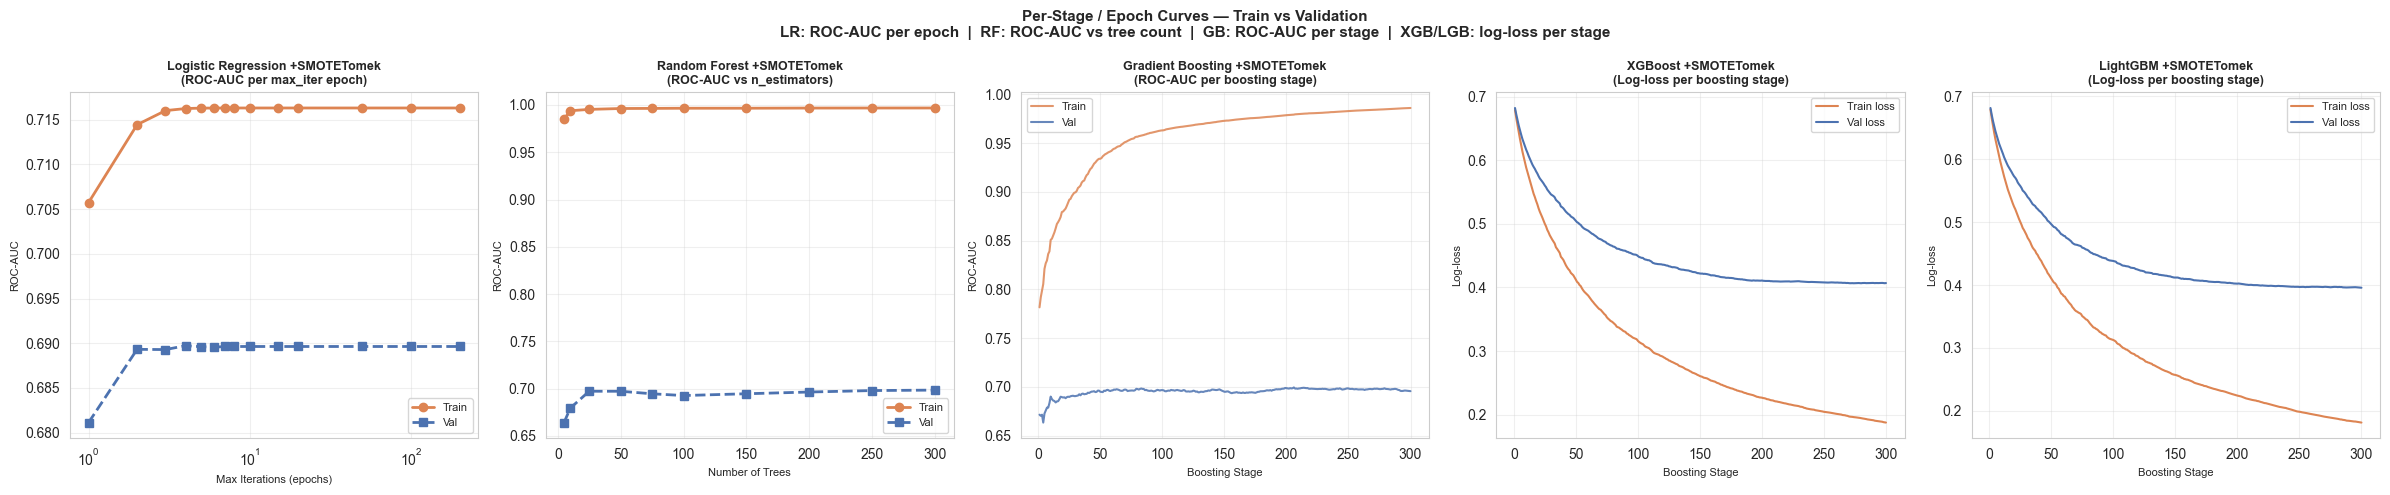


Saved: stage_epoch_curves_smotetomek.png


In [9]:

# ── Helper: extract fitted preprocessor + SMOTE+Tomek'd training data ──────────
def get_preprocessed_smotetomek(model_name):
    """Return (X_train_res, y_train_res, X_test_prep) using the fitted pipeline's preprocessor."""
    pipe = imp_trained_pipelines[model_name]
    prep = pipe.named_steps['preprocessor']          # already fitted ColumnTransformer
    X_tr_prep = prep.transform(X_train)
    X_te_prep = prep.transform(X_test)
    smotetomek_tmp = SMOTETomek(random_state=RANDOM_STATE)
    X_tr_res, y_tr_res = smotetomek_tmp.fit_resample(X_tr_prep, y_train)
    return X_tr_res, y_tr_res, X_te_prep

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

# ── 1. Gradient Boosting: staged_predict_proba ────────────────────────────
print('GB staged curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smotetomek('Gradient Boosting + SMOTETomek')
clf_gb = imp_trained_pipelines['Gradient Boosting + SMOTETomek'].named_steps['classifier']

gb_train, gb_val = [], []
for proba in clf_gb.staged_predict_proba(X_tr_res):
    gb_train.append(roc_auc_score(y_tr_res, proba[:, 1]))
for proba in clf_gb.staged_predict_proba(X_te_prep):
    gb_val.append(roc_auc_score(y_test, proba[:, 1]))

stages = np.arange(1, len(gb_train) + 1)
ax = axes[2]
ax.plot(stages, gb_train, color='#DD8452', linewidth=1.5, label='Train', alpha=0.85)
ax.plot(stages, gb_val,   color='#4C72B0', linewidth=1.5, label='Val',   alpha=0.85)
ax.set_title('Gradient Boosting +SMOTETomek\n(ROC-AUC per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. XGBoost: eval_set → log-loss per stage ─────────────────────────────
print('XGBoost staged curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smotetomek('XGBoost + SMOTETomek')
xgb_stage = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1, verbosity=0
)
xgb_stage.fit(X_tr_res, y_tr_res,
               eval_set=[(X_tr_res, y_tr_res), (X_te_prep, y_test)],
               verbose=False)
xgb_res    = xgb_stage.evals_result_
xgb_stages = np.arange(1, len(xgb_res['validation_0']['logloss']) + 1)

ax = axes[3]
ax.plot(xgb_stages, xgb_res['validation_0']['logloss'], color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(xgb_stages, xgb_res['validation_1']['logloss'], color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('XGBoost +SMOTETomek\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 3. LightGBM: eval_set → log-loss per stage ────────────────────────────
print('LightGBM staged curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smotetomek('LightGBM + SMOTETomek')
lgb_stage = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

import lightgbm as lgb_lib
lgb_stage.fit(X_tr_res, y_tr_res,
               eval_set=[(X_tr_res, y_tr_res), (X_te_prep, y_test)],
               eval_metric='binary_logloss',
               callbacks=[lgb_lib.record_evaluation(evals_result := {})])
lgb_stages = np.arange(1, 301)

ax = axes[4]
ax.plot(lgb_stages, list(evals_result['training']['binary_logloss']),    color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(lgb_stages, list(evals_result['valid_1']['binary_logloss']),     color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('LightGBM +SMOTETomek\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. Random Forest: ROC-AUC vs n_estimators ────────────────────────────
print('Random Forest tree-count curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smotetomek('Random Forest + SMOTETomek')
rf_counts = [5, 10, 25, 50, 75, 100, 150, 200, 250, 300]
rf_train, rf_val = [], []
for n in rf_counts:
    rf_tmp = RandomForestClassifier(n_estimators=n, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
    rf_tmp.fit(X_tr_res, y_tr_res)
    rf_train.append(roc_auc_score(y_tr_res,  rf_tmp.predict_proba(X_tr_res)[:, 1]))
    rf_val.append(  roc_auc_score(y_test,    rf_tmp.predict_proba(X_te_prep)[:, 1]))

ax = axes[1]
ax.plot(rf_counts, rf_train, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(rf_counts, rf_val,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Random Forest +SMOTETomek\n(ROC-AUC vs n_estimators)', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of Trees', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 5. Logistic Regression: ROC-AUC per epoch (max_iter) ──────────────────
print('Logistic Regression epoch curve...', flush=True)
X_tr_res, y_tr_res, X_te_prep = get_preprocessed_smotetomek('Logistic Regression + SMOTETomek')
lr_iters = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 50, 100, 200]
lr_train, lr_val = [], []
for mi in lr_iters:
    lr_tmp = LogisticRegression(max_iter=mi, random_state=RANDOM_STATE,
                                 class_weight=None, solver='lbfgs')
    lr_tmp.fit(X_tr_res, y_tr_res)
    lr_train.append(roc_auc_score(y_tr_res, lr_tmp.predict_proba(X_tr_res)[:, 1]))
    lr_val.append(  roc_auc_score(y_test,  lr_tmp.predict_proba(X_te_prep)[:, 1]))

ax = axes[0]
ax.plot(lr_iters, lr_train, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(lr_iters, lr_val,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Logistic Regression +SMOTETomek\n(ROC-AUC per max_iter epoch)', fontweight='bold', fontsize=9)
ax.set_xlabel('Max Iterations (epochs)', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.set_xscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Per-Stage / Epoch Curves — Train vs Validation\n'
    'LR: ROC-AUC per epoch  |  RF: ROC-AUC vs tree count  |  GB: ROC-AUC per stage  |  XGB/LGB: log-loss per stage',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/stage_epoch_curves_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: stage_epoch_curves_smotetomek.png')

### 5c. Results Visualisation

Benchmark bar chart, ROC-AUC/F1 ranking, ROC curves, and confusion matrices for all 5 SMOTE+Tomek models.

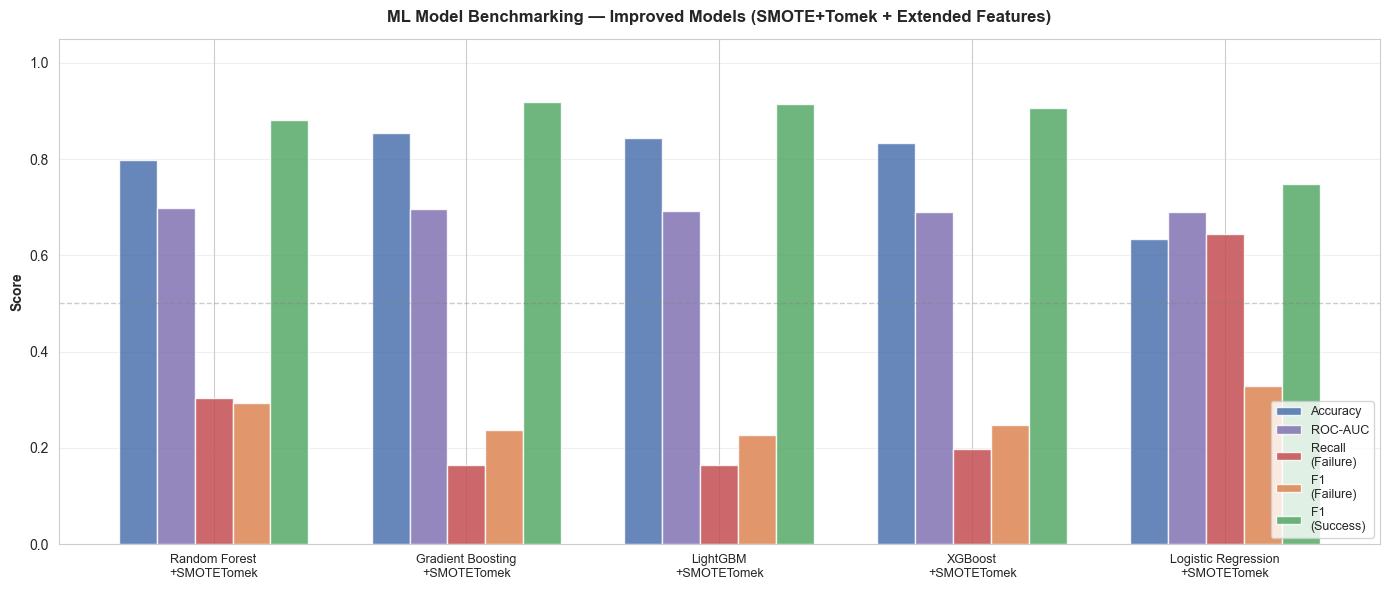

Saved: benchmark_comparison_smotetomek.png


In [10]:

# ── Benchmark comparison bar chart — all 5 SMOTE+Tomek models ──────────────
metrics_to_plot  = ['Accuracy', 'ROC-AUC', 'Recall (Failure)', 'F1 (Failure)', 'F1 (Success)']
metric_labels    = ['Accuracy', 'ROC-AUC', 'Recall\n(Failure)', 'F1\n(Failure)', 'F1\n(Success)']
plot_imp = imp_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_imp))
width = 0.15
colors_ = ['#4C72B0', '#8172B2', '#C44E52', '#DD8452', '#55A868']

for i, (metric, label, color) in enumerate(zip(metrics_to_plot, metric_labels, colors_)):
    bars_ = ax.bar(x + i * width, plot_imp[metric].values, width,
                   label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels([n.replace(' + SMOTETomek', '\n+SMOTETomek') for n in plot_imp.index],
                    rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('ML Model Benchmarking — Improved Models (SMOTE+Tomek + Extended Features)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('smotetomek_outputs/images/benchmark_comparison_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison_smotetomek.png')

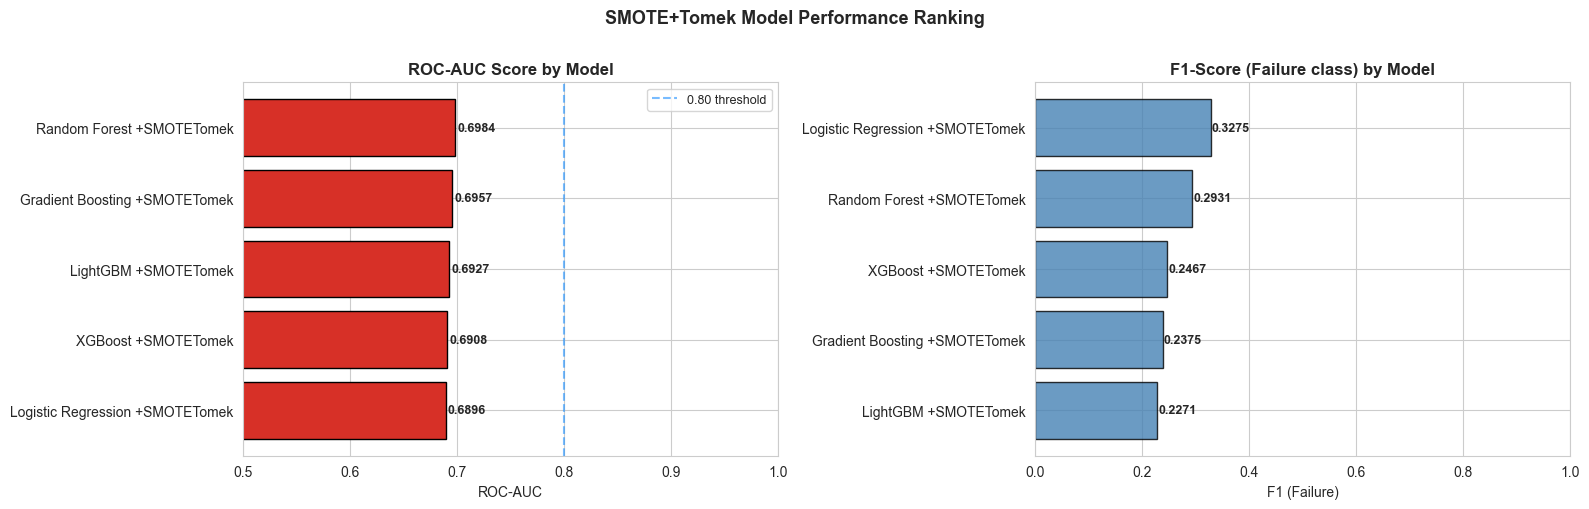

Saved: model_ranking_smotetomek.png


In [11]:

# ── ROC-AUC & F1 (Failure) ranking ────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_roc = imp_df.sort_values('ROC-AUC', ascending=True)
colors_roc = ['#d73027' if v < 0.70 else '#fee08b' if v < 0.80 else '#1a9850'
               for v in sorted_roc['ROC-AUC']]
bars = axes[0].barh([n.replace(' + SMOTETomek', ' +SMOTETomek') for n in sorted_roc['Model']],
                    sorted_roc['ROC-AUC'], color=colors_roc, edgecolor='black')
for bar, val in zip(bars, sorted_roc['ROC-AUC']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.8, color='dodgerblue', linestyle='--', alpha=0.6, label='0.80 threshold')
axes[0].legend(fontsize=9)
axes[0].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[0].set_xlabel('ROC-AUC')

sorted_f1 = imp_df.sort_values('F1 (Failure)', ascending=True)
bars2 = axes[1].barh([n.replace(' + SMOTETomek', ' +SMOTETomek') for n in sorted_f1['Model']],
                     sorted_f1['F1 (Failure)'], color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars2, sorted_f1['F1 (Failure)']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, 1.0)
axes[1].set_title('F1-Score (Failure class) by Model', fontweight='bold')
axes[1].set_xlabel('F1 (Failure)')

plt.suptitle('SMOTE+Tomek Model Performance Ranking', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/model_ranking_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_ranking_smotetomek.png')

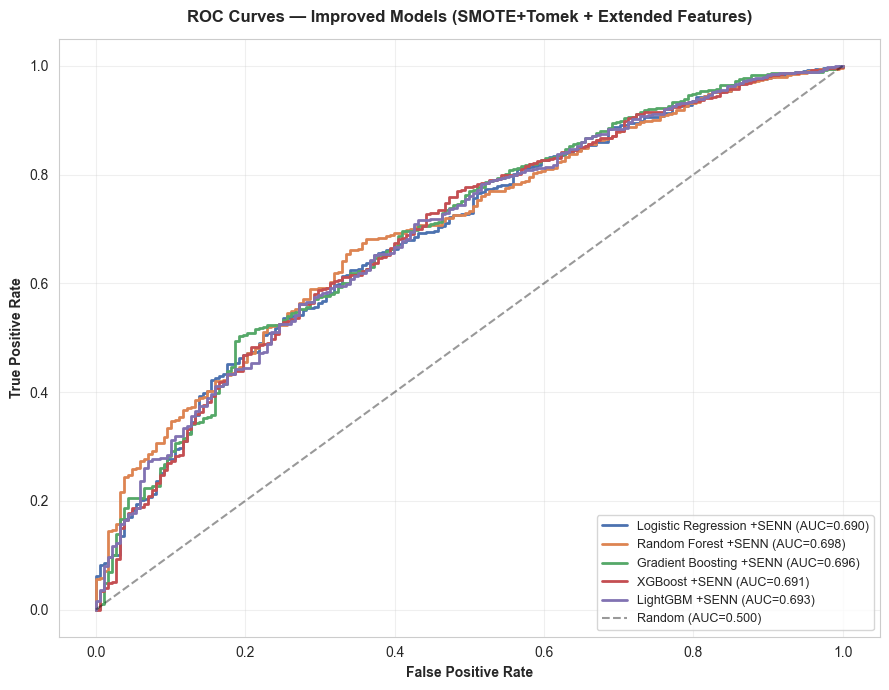

Saved: roc_curves_smotetomek.png


In [12]:

# ── ROC Curves — all 5 SMOTE+Tomek models ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc_lines = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for (name, pipe), color in zip(imp_trained_pipelines.items(), colors_roc_lines):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    short = name.replace(' + SMOTETomek', ' +SENN')
    ax.plot(fpr, tpr, label=f'{short} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — Improved Models (SMOTE+Tomek + Extended Features)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smotetomek_outputs/images/roc_curves_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_smotetomek.png')

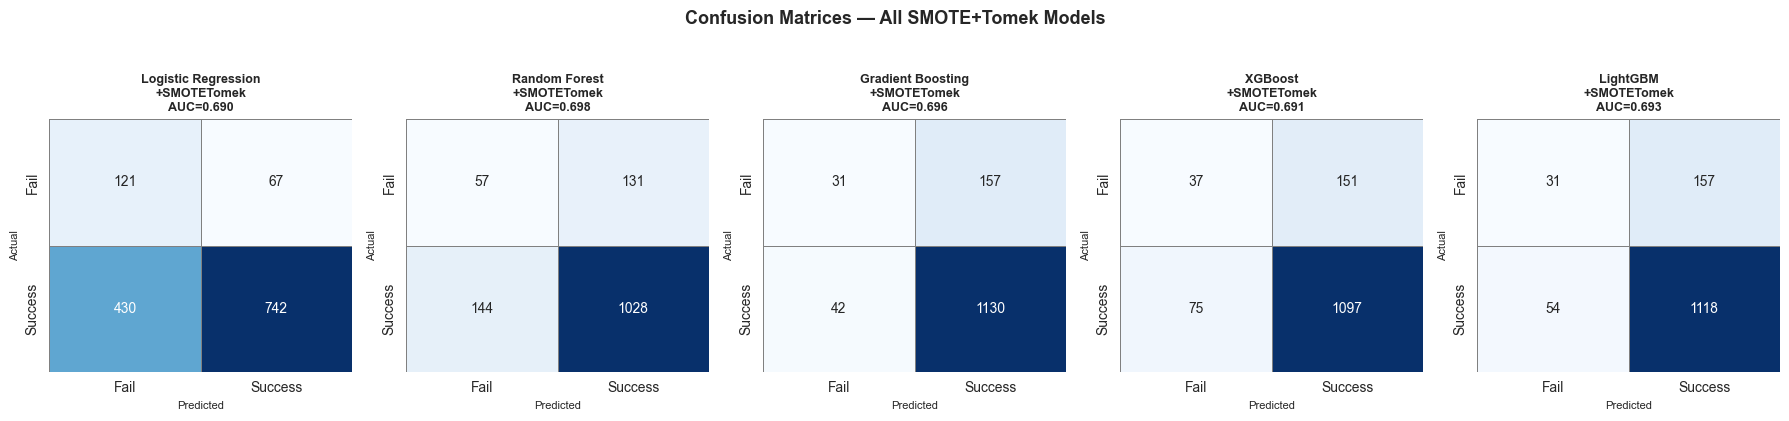

Saved: confusion_matrices_all_smotetomek.png


In [13]:

# ── Confusion matrices grid — all 5 SMOTE+Tomek models ─────────────────────
n_imp     = len(imp_trained_pipelines)
fig, axes = plt.subplots(1, n_imp, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, imp_trained_pipelines.items()):
    yp   = pipe.predict(X_test)
    cm_  = confusion_matrix(y_test, yp)
    auc  = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    ax.set_title(f'{name.replace(" + SMOTETomek", chr(10)+"+SMOTETomek")}\nAUC={auc:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices — All SMOTE+Tomek Models', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/confusion_matrices_all_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all_smotetomek.png')

## 6. Baseline vs SMOTE+Tomek Comparison

In [14]:
# ── Load baseline results for comparison ──────────────────────────────────
baseline_df = pd.read_csv('baseline_outputs/ml_benchmark_results.csv')
print(f'Loaded baseline results: {len(baseline_df)} models')
print(baseline_df[['Model', 'ROC-AUC', 'F1-Score']].to_string(index=False))

Loaded baseline results: 12 models
              Model  ROC-AUC  F1-Score
          SVM (RBF) 0.696116  0.758105
           AdaBoost 0.695803  0.925750
Logistic Regression 0.691664  0.743525
  Gradient Boosting 0.688095  0.924791
 MLP Neural Network 0.688002  0.925692
            XGBoost 0.681405  0.786538
           LightGBM 0.678875  0.799237
        Extra Trees 0.672877  0.830258
      Random Forest 0.670574  0.859895
      Decision Tree 0.640551  0.694459
K-Nearest Neighbors 0.628272  0.919135
        Naive Bayes 0.624630  0.907536


In [15]:
# ── Re-train top-5 baseline models on same split for fair comparison ──────
# (Same data, same split, but baseline features only — no resampling)
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier as RF, GradientBoostingClassifier as GB

BASELINE_FEATURES = [
    'Age', 'Days_To_Treatment', 'Year', 'Sex', 'Anatomical Site',
    'Registration Group', 'Bacteriologic Status', 'Microscopy Result',
    'Source of Patient', 'Type', 'Province',
]

baseline_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

# Use the same df / split indices for fair comparison
X_base = df[BASELINE_FEATURES].copy()
X_base['Age'] = X_base['Age'].fillna(df['Computed_Age'])
X_base_train = X_base.loc[X_train.index]
X_base_test  = X_base.loc[X_test.index]

BASELINE_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / y_train.sum(),
        n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced',
        n_jobs=-1, verbose=-1
    ),
}

baseline_trained = {}
for name, model in BASELINE_MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', baseline_preprocessor), ('classifier', model)])
    pipe.fit(X_base_train, y_train)
    baseline_trained[name] = pipe

print(f'Re-trained {len(BASELINE_MODELS)} baseline models on same data split for fair comparison.')

Re-trained 5 baseline models on same data split for fair comparison.


In [16]:
# ── Side-by-side comparison ───────────────────────────────────────────────
baseline_lookup = {
    'Logistic Regression + SMOTETomek': 'Logistic Regression',
    'Random Forest + SMOTETomek':       'Random Forest',
    'Gradient Boosting + SMOTETomek':   'Gradient Boosting',
    'XGBoost + SMOTETomek':             'XGBoost',
    'LightGBM + SMOTETomek':            'LightGBM',
}

compare_rows = []
for imp_name, base_name in baseline_lookup.items():
    imp_row = imp_df[imp_df['Model'] == imp_name].iloc[0]

    # Baseline metrics from re-trained models on same split
    base_pipe = baseline_trained[base_name]
    base_pred = base_pipe.predict(X_base_test)
    base_proba = base_pipe.predict_proba(X_base_test)[:, 1]
    base_rep = classification_report(y_test, base_pred,
                                     target_names=['Failure', 'Success'],
                                     output_dict=True, zero_division=0)
    base_auc = roc_auc_score(y_test, base_proba)

    compare_rows.append({
        'Model':                     base_name,
        'Baseline ROC-AUC':          base_auc,
        'SMOTETomek ROC-AUC':          imp_row['ROC-AUC'],
        'ΔAUC':                      imp_row['ROC-AUC'] - base_auc,
        'Baseline Recall (Fail)':    base_rep['Failure']['recall'],
        'SMOTETomek Recall (Fail)':    imp_row['Recall (Failure)'],
        'ΔRecall (Fail)':            imp_row['Recall (Failure)'] - base_rep['Failure']['recall'],
    })

compare_df = pd.DataFrame(compare_rows)

print('Baseline → SMOTE+Tomek Comparison (same data split):')
print(compare_df.to_string(index=False, float_format='{:.4f}'.format))

Baseline → SMOTE+Tomek Comparison (same data split):
              Model  Baseline ROC-AUC  SMOTETomek ROC-AUC    ΔAUC  Baseline Recall (Fail)  SMOTETomek Recall (Fail)  ΔRecall (Fail)
Logistic Regression            0.6917              0.6896 -0.0020                  0.6543                    0.6436         -0.0106
      Random Forest            0.6706              0.6984  0.0279                  0.3085                    0.3032         -0.0053
  Gradient Boosting            0.6881              0.6957  0.0076                  0.0479                    0.1649          0.1170
            XGBoost            0.6814              0.6908  0.0094                  0.5213                    0.1968         -0.3245
           LightGBM            0.6789              0.6927  0.0138                  0.5372                    0.1649         -0.3723


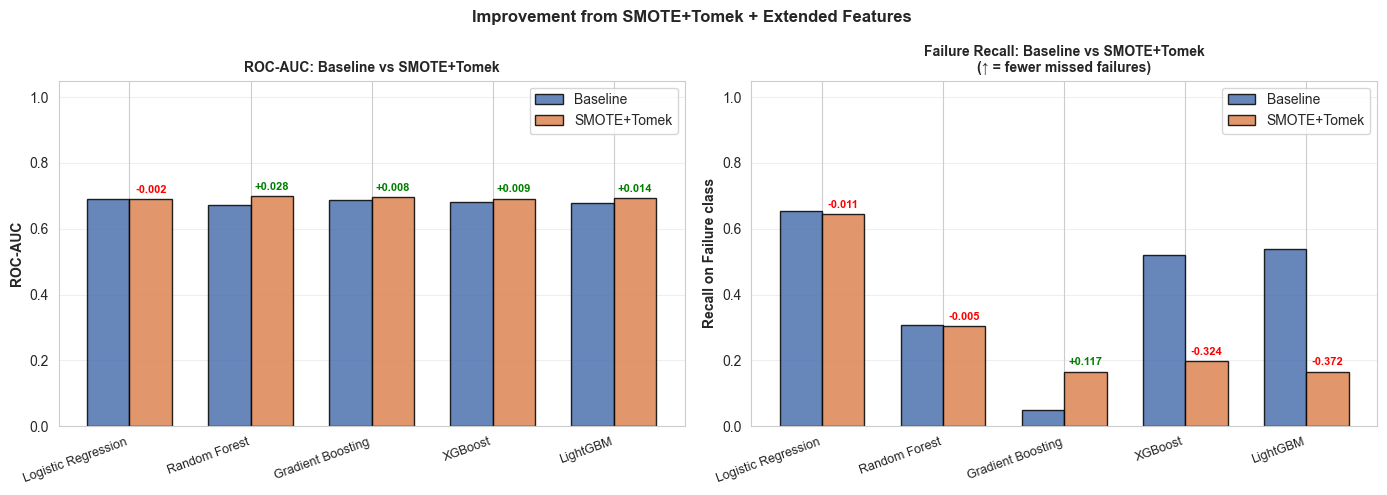

Saved: baseline_vs_smotetomek.png


In [17]:
# ── Grouped bar chart: Baseline vs SMOTE+Tomek ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_labels = [r for r in compare_df['Model']]
x = np.arange(len(model_labels))
w = 0.35

for ax, base_col, imp_col, title, ylabel in [
    (axes[0], 'Baseline ROC-AUC', 'SMOTETomek ROC-AUC', 'ROC-AUC: Baseline vs SMOTE+Tomek', 'ROC-AUC'),
    (axes[1], 'Baseline Recall (Fail)', 'SMOTETomek Recall (Fail)',
     'Failure Recall: Baseline vs SMOTE+Tomek\n(↑ = fewer missed failures)', 'Recall on Failure class'),
]:
    b1 = ax.bar(x - w/2, compare_df[base_col], w, label='Baseline', color='#4C72B0', alpha=0.85, edgecolor='black')
    b2 = ax.bar(x + w/2, compare_df[imp_col],  w, label='SMOTE+Tomek', color='#DD8452', alpha=0.85, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    # Delta labels
    for xi, (bv, iv) in enumerate(zip(compare_df[base_col], compare_df[imp_col])):
        delta = iv - bv
        color = 'green' if delta > 0 else 'red'
        ax.text(xi + w/2, iv + 0.02, f'{delta:+.3f}', ha='center', fontsize=8,
                color=color, fontweight='bold')

plt.suptitle('Improvement from SMOTE+Tomek + Extended Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/baseline_vs_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_vs_smotetomek.png')

## 7. Best SMOTE+Tomek Model — Detailed Analysis

In [18]:
# ── Best SMOTE+Tomek model: detailed report & confusion matrix ──────────────
best_imp_name = imp_df.iloc[0]['Model']
best_imp_pipe = imp_trained_pipelines[best_imp_name]
y_pred_best   = best_imp_pipe.predict(X_test)
y_proba_best  = best_imp_pipe.predict_proba(X_test)[:, 1]

print(f'Best SMOTE+Tomek model: {best_imp_name}')
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print()
print(classification_report(y_test, y_pred_best,
                             target_names=['Failure (0)', 'Success (1)'], zero_division=0))

Best SMOTE+Tomek model: Random Forest + SMOTETomek
  ROC-AUC: 0.6984

              precision    recall  f1-score   support

 Failure (0)       0.28      0.30      0.29       188
 Success (1)       0.89      0.88      0.88      1172

    accuracy                           0.80      1360
   macro avg       0.59      0.59      0.59      1360
weighted avg       0.80      0.80      0.80      1360



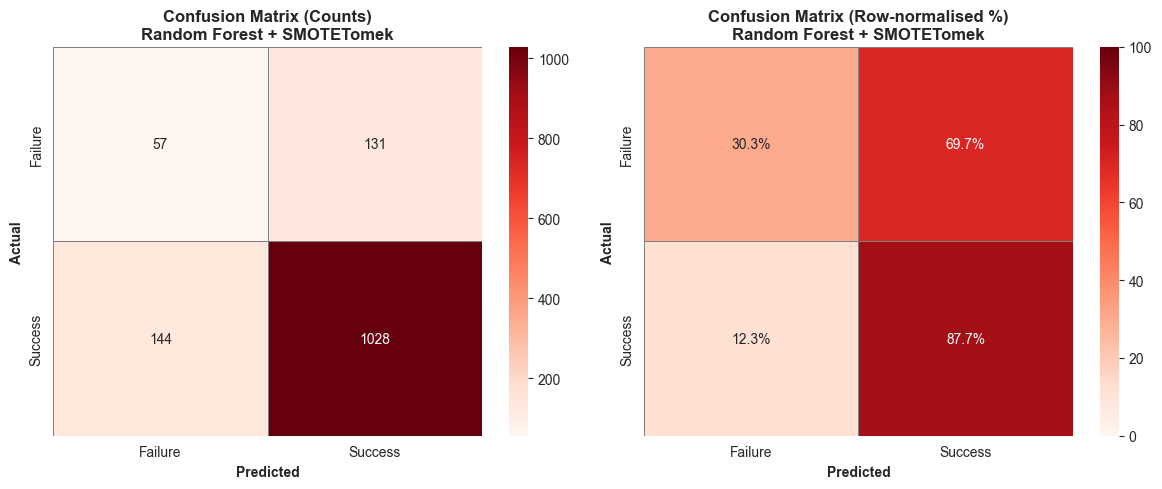

Saved: confusion_matrix_best_smotetomek.png


In [19]:

# ── Best SMOTE+Tomek model — dual confusion matrix (counts + normalised %) ──
cm_best = confusion_matrix(y_test, y_pred_best)
cm_best_pct = cm_best.astype(float) / cm_best.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_imp_name}', fontweight='bold')

labels_pct = [[f'{v:.1f}%' for v in row] for row in cm_best_pct]
sns.heatmap(cm_best_pct, annot=labels_pct, fmt='', cmap='Reds', ax=axes[1],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title(f'Confusion Matrix (Row-normalised %)\n{best_imp_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('smotetomek_outputs/images/confusion_matrix_best_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_best_smotetomek.png')

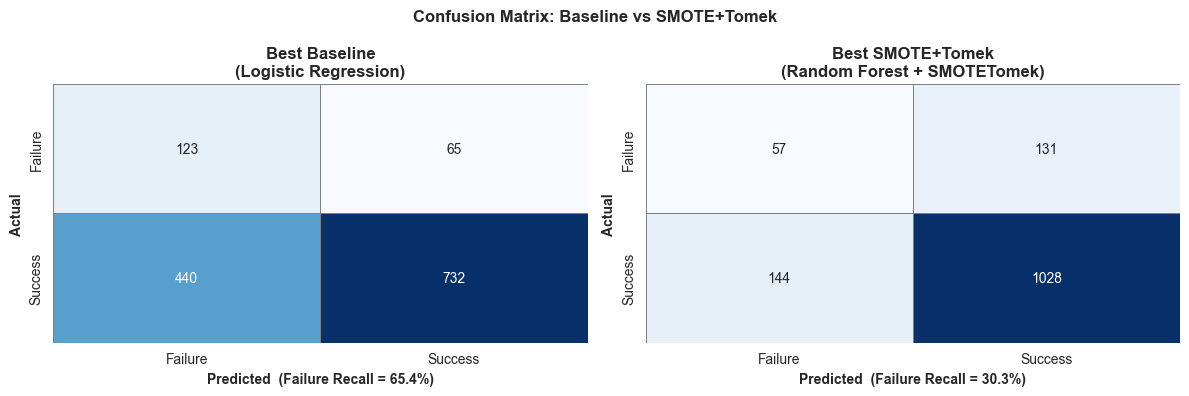

In [20]:
# ── Confusion matrices: best baseline vs best SMOTE+Tomek ───────────────────
best_base_auc = 0
best_base_name = ''
for name, pipe in baseline_trained.items():
    auc = roc_auc_score(y_test, pipe.predict_proba(X_base_test)[:, 1])
    if auc > best_base_auc:
        best_base_auc = auc
        best_base_name = name

best_base_pred = baseline_trained[best_base_name].predict(X_base_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
titles = [
    f'Best Baseline\n({best_base_name})',
    f'Best SMOTE+Tomek\n({best_imp_name})',
]
test_sets = [
    (y_test, best_base_pred),
    (y_test, y_pred_best),
]

for ax, (yt, yp), title in zip(axes, test_sets, titles):
    cm_ = confusion_matrix(yt, yp)
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')
    tn, fp, fn, tp = cm_.ravel()
    fail_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    ax.set_xlabel(f'Predicted  (Failure Recall = {fail_recall:.1%})', fontweight='bold')

plt.suptitle('Confusion Matrix: Baseline vs SMOTE+Tomek', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/cm_baseline_vs_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

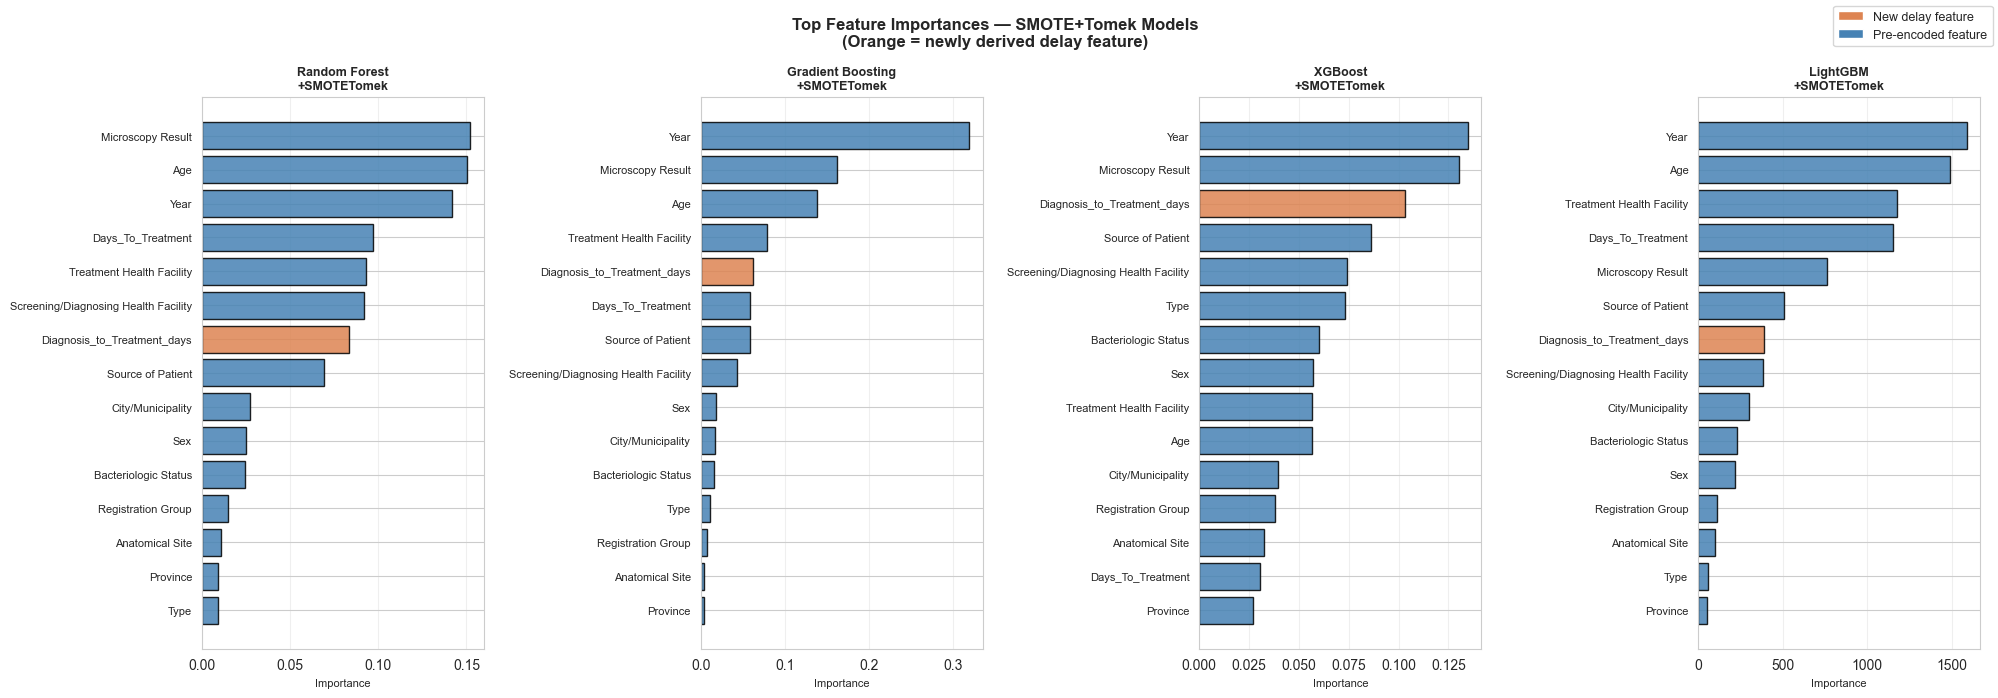

Saved: feature_importance_smotetomek.png


In [21]:
# ── Feature importance of SMOTE+Tomek tree models ────────────────────────────
tree_imp_models = {k: v for k, v in imp_trained_pipelines.items()
                   if any(m in k for m in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM'])}

def get_imp_feature_names(pipe):
    return PRE_ENCODED_FEATURES + DERIVED_FEATURES

fig, axes = plt.subplots(1, len(tree_imp_models), figsize=(20, 7))

for ax, (name, pipe) in zip(axes, tree_imp_models.items()):
    clf         = pipe.named_steps['classifier']
    feat_names  = get_imp_feature_names(pipe)
    importances = clf.feature_importances_

    top_n = min(15, len(feat_names))
    top_idx  = np.argsort(importances)[-top_n:]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    # Highlight the new delay feature in orange
    delay_feats = {'Diagnosis_to_Treatment_days'}
    colors_ = ['#DD8452' if n in delay_feats else 'steelblue' for n in top_names]

    ax.barh(range(top_n), top_vals, color=colors_, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(name.replace(' + SMOTETomek', '\n+SMOTETomek'), fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

# Legend
legend_elements = [Patch(facecolor='#DD8452', label='New delay feature'),
                   Patch(facecolor='steelblue', label='Pre-encoded feature')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Top Feature Importances — SMOTE+Tomek Models\n(Orange = newly derived delay feature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/feature_importance_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_smotetomek.png')

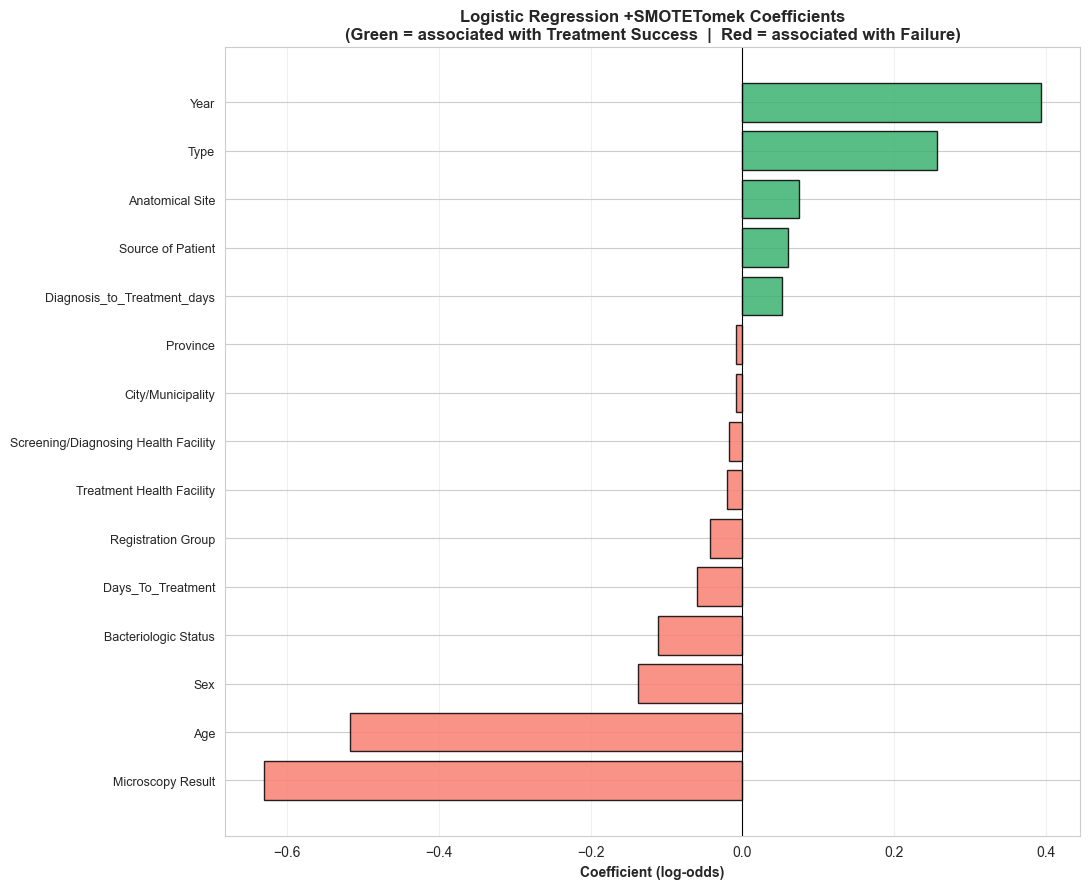

Saved: logreg_coefficients_smotetomek.png


In [22]:

# ── Logistic Regression +SMOTETomek coefficients ─────────────────────────────
lr_imp_pipe = imp_trained_pipelines['Logistic Regression + SMOTETomek']
lr_imp_clf  = lr_imp_pipe.named_steps['classifier']
feat_names_lr = PRE_ENCODED_FEATURES + DERIVED_FEATURES

coefs_lr   = lr_imp_clf.coef_[0]
sorted_lr  = np.argsort(coefs_lr)
x_vals_lr  = coefs_lr[sorted_lr]
x_names_lr = [feat_names_lr[i] for i in sorted_lr]
colors_lr  = ['salmon' if v < 0 else 'mediumseagreen' for v in x_vals_lr]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(range(len(x_vals_lr)), x_vals_lr, color=colors_lr, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(x_vals_lr)))
ax.set_yticklabels(x_names_lr, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)', fontweight='bold')
ax.set_title(
    'Logistic Regression +SMOTETomek Coefficients\n'
    '(Green = associated with Treatment Success  |  Red = associated with Failure)',
    fontweight='bold'
)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('smotetomek_outputs/images/logreg_coefficients_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: logreg_coefficients_smotetomek.png')

## 9. Cross-Validation — SMOTE+Tomek Models

5-fold stratified CV on the training set using the same ImbPipeline (SMOTE+Tomek applied inside each fold).

In [23]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# ── 5-fold stratified CV — all 5 SMOTE+Tomek models ─────────────────────────
# SMOTE+Tomek is inside the ImbPipeline so it is applied only on training folds.
cv_imp = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_imp_results = []

for name, pipe in imp_trained_pipelines.items():
    print(f'CV: {name}...', end=' ', flush=True)
    scores = cross_validate(
        clone(pipe), X_train, y_train, cv=cv_imp,
        scoring=['accuracy', 'f1', 'roc_auc', 'recall', 'precision'],
        n_jobs=-1
    )
    cv_imp_results.append({
        'Model':        name.replace(' + SMOTETomek', ' +SMOTETomek'),
        'CV Accuracy':  f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV F1':        f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':   f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'CV Recall':    f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
    })
    print('done')

cv_imp_df = pd.DataFrame(cv_imp_results)
print('\n5-Fold Stratified Cross-Validation Results (SMOTE+Tomek Models):')
print(cv_imp_df.to_string(index=False))

CV: Logistic Regression + SMOTETomek... done
CV: Random Forest + SMOTETomek... done
CV: Gradient Boosting + SMOTETomek... done
CV: XGBoost + SMOTETomek... done
CV: LightGBM + SMOTETomek... done

5-Fold Stratified Cross-Validation Results (SMOTE+Tomek Models):
                          Model     CV Accuracy           CV F1      CV ROC-AUC       CV Recall    CV Precision
Logistic Regression +SMOTETomek 0.6413 ± 0.0120 0.7551 ± 0.0096 0.6917 ± 0.0170 0.6417 ± 0.0123 0.9173 ± 0.0049
      Random Forest +SMOTETomek 0.8014 ± 0.0182 0.8832 ± 0.0119 0.7104 ± 0.0184 0.8726 ± 0.0211 0.8943 ± 0.0035
  Gradient Boosting +SMOTETomek 0.8438 ± 0.0094 0.9128 ± 0.0058 0.7087 ± 0.0187 0.9486 ± 0.0131 0.8797 ± 0.0028
            XGBoost +SMOTETomek 0.8409 ± 0.0097 0.9106 ± 0.0059 0.7047 ± 0.0176 0.9405 ± 0.0118 0.8826 ± 0.0033
           LightGBM +SMOTETomek 0.8470 ± 0.0094 0.9147 ± 0.0056 0.7067 ± 0.0198 0.9518 ± 0.0107 0.8804 ± 0.0020


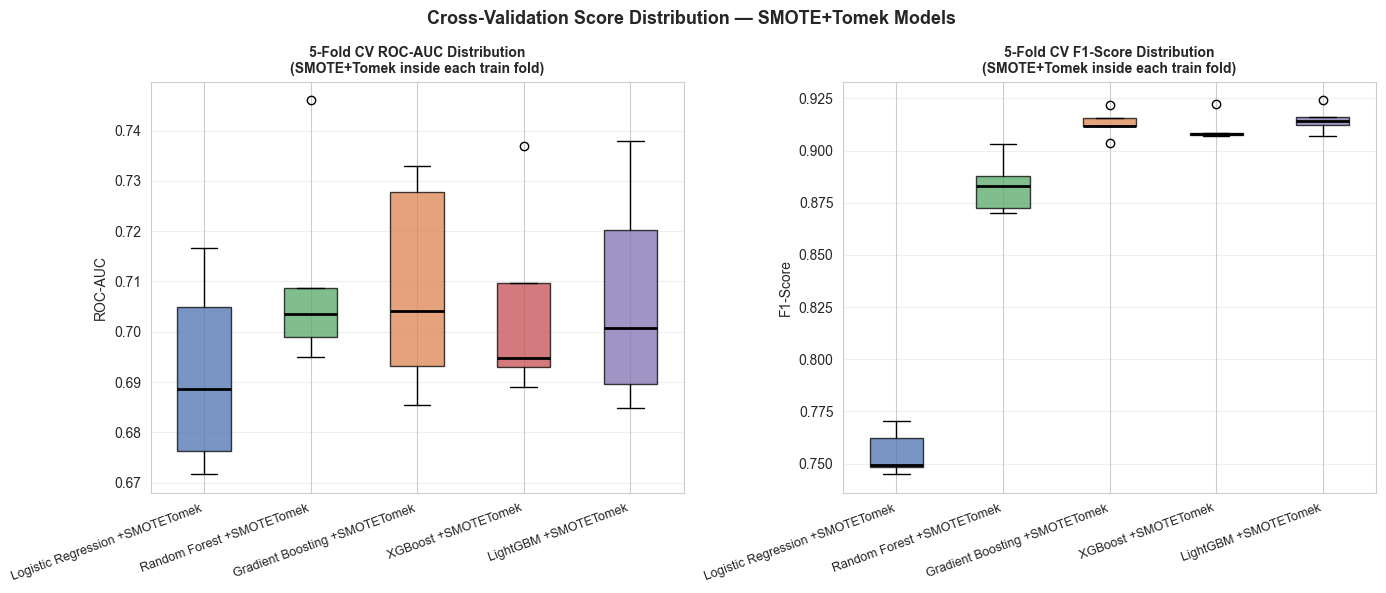

Saved: cv_boxplots_smotetomek.png


In [24]:

# ── CV ROC-AUC & F1 boxplots ──────────────────────────────────────────────
cv_box_imp = {}
for name, pipe in imp_trained_pipelines.items():
    scores = cross_validate(clone(pipe), X_train, y_train, cv=cv_imp,
                            scoring=['roc_auc', 'f1'], n_jobs=-1)
    cv_box_imp[name.replace(' + SMOTETomek', ' +SMOTETomek')] = {
        'roc_auc': scores['test_roc_auc'],
        'f1':      scores['test_f1'],
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_box_imp = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for ax, metric, title in zip(axes, ['roc_auc', 'f1'], ['ROC-AUC', 'F1-Score']):
    box_vals = [cv_box_imp[n][metric] for n in cv_box_imp]
    bp = ax.boxplot(box_vals, labels=list(cv_box_imp.keys()), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_box_imp):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(list(cv_box_imp.keys()), rotation=20, ha='right', fontsize=9)
    ax.set_title(f'5-Fold CV {title} Distribution\n(SMOTE+Tomek inside each train fold)',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Score Distribution — SMOTE+Tomek Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smotetomek_outputs/images/cv_boxplots_smotetomek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_boxplots_smotetomek.png')

## 10. Save Results

In [25]:
# ── Save best SMOTE+Tomek model and results ─────────────────────────────────
safe_name = best_imp_name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'plus')
joblib.dump(best_imp_pipe, f'smotetomek_outputs/models/smotetomek_best_{safe_name}.pkl')
imp_df.to_csv('smotetomek_outputs/smotetomek_model_results.csv', index=False)
compare_df.to_csv('smotetomek_outputs/baseline_vs_smotetomek_comparison.csv', index=False)
cv_imp_df.to_csv('smotetomek_outputs/cv_smotetomek_results.csv', index=False)

print(f'Saved best SMOTE+Tomek model  : smotetomek_outputs/models/smotetomek_best_{safe_name}.pkl')
print(f'Saved SMOTE+Tomek results     : smotetomek_outputs/smotetomek_model_results.csv')
print(f'Saved comparison summary    : smotetomek_outputs/baseline_vs_smotetomek_comparison.csv')
print(f'Saved CV results            : smotetomek_outputs/cv_smotetomek_results.csv')

Saved best SMOTE+Tomek model  : smotetomek_outputs/models/smotetomek_best_Random_Forest_plus_SMOTETomek.pkl
Saved SMOTE+Tomek results     : smotetomek_outputs/smotetomek_model_results.csv
Saved comparison summary    : smotetomek_outputs/baseline_vs_smotetomek_comparison.csv
Saved CV results            : smotetomek_outputs/cv_smotetomek_results.csv


## 11. Summary

In [26]:
# ── Improvement summary ───────────────────────────────────────────────────
print('='*70)
print('  SMOTE+Tomek IMPROVEMENT SUMMARY')
print('='*70)
print(f'  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)')
print(f'  Records : {len(df):,} (Success: {y.sum():,} | Failure: {(y==0).sum():,})')
print(f'  Features: {len(IMP_FEATURES)} (baseline {len(IMP_FEATURES)-4} + 3 geographic + 1 derived delay)')
print(f'  Split   : 80% train / 20% test (stratified) + SMOTE+Tomek on train set')
print()
print(f'  Best SMOTE+Tomek Model: {best_imp_name}')
print(f'  ROC-AUC: {imp_df.iloc[0]["ROC-AUC"]:.4f}')
print()
for _, row in compare_df.iterrows():
    auc_arrow  = '↑' if row['ΔAUC'] > 0 else '↓'
    rec_arrow  = '↑' if row['ΔRecall (Fail)'] > 0 else '↓'
    print(f"  {row['Model']:<25}  "
          f"AUC {row['Baseline ROC-AUC']:.3f}→{row['SMOTETomek ROC-AUC']:.3f} ({auc_arrow}{abs(row['ΔAUC']):.3f})  "
          f"FailRecall {row['Baseline Recall (Fail)']:.3f}→{row['SMOTETomek Recall (Fail)']:.3f} ({rec_arrow}{abs(row['ΔRecall (Fail)']):.3f})")
print('='*70)
print()
print('  Outputs saved to smotetomek_outputs/')
print('    • smotetomek_model_results.csv')
print('    • baseline_vs_smotetomek_comparison.csv')
print('    • cv_smotetomek_results.csv')
print('    • models/smotetomek_best_*.pkl')
print('    • images/*.png')
print('='*70)

  SMOTE+Tomek IMPROVEMENT SUMMARY
  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)
  Records : 6,797 (Success: 5,858 | Failure: 939)
  Features: 15 (baseline 11 + 3 geographic + 1 derived delay)
  Split   : 80% train / 20% test (stratified) + SMOTE+Tomek on train set

  Best SMOTE+Tomek Model: Random Forest + SMOTETomek
  ROC-AUC: 0.6984

  Logistic Regression        AUC 0.692→0.690 (↓0.002)  FailRecall 0.654→0.644 (↓0.011)
  Random Forest              AUC 0.671→0.698 (↑0.028)  FailRecall 0.309→0.303 (↓0.005)
  Gradient Boosting          AUC 0.688→0.696 (↑0.008)  FailRecall 0.048→0.165 (↑0.117)
  XGBoost                    AUC 0.681→0.691 (↑0.009)  FailRecall 0.521→0.197 (↓0.324)
  LightGBM                   AUC 0.679→0.693 (↑0.014)  FailRecall 0.537→0.165 (↓0.372)

  Outputs saved to smotetomek_outputs/
    • smotetomek_model_results.csv
    • baseline_vs_smotetomek_comparison.csv
    • cv_smotetomek_results.csv
    • models/smotetomek_best_*.pkl
    • images/*.png
